# Multiplex Dataset Profiling
Data and target distribution + curve visualisations for `curve_for_training_ml.joblib`.

In [5]:
import sys, math
from pathlib import Path
from collections import Counter

import joblib
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

DATA_ROOT = Path('/vol/bitbucket/gk225/POC_DDM_datasets/LAB_Multiplex')
# DATASETS  = ['01_ACA_qdPCR', '02_ACA_qdPCR_balanced']
DATASETS  = ['02_ACA_qdPCR_balanced']
CURVE_KEY = 'ori_curves'                    # inside d['curves']
MAX_CURVES_PLOT = 300                       # max individual curves per label
ALPHA_SINGLE = 0.015                        # individual curve alpha

# colour per target (plus mix colours for multi-target labels)
BASE_COLORS = {'KPC': '#E64A19', 'NDM': '#1565C0', 'VIM': '#2E7D32'}


LABEL_REMAP  = {'KPC_NDM': 'NDM_KPC', 'KPC_VIM': 'VIM_KPC', 'KPC_NDM_VIM': 'NDM_VIM_KPC'}
LABEL_ORDER  = ['NDM', 'VIM', 'KPC', 'NDM_VIM', 'NDM_KPC', 'VIM_KPC', 'NDM_VIM_KPC']


## Data & Target Distribution
Counts per unique well-label for each dataset.


=== 02_ACA_qdPCR_balanced  (N=10,383) ===
  all_targets : ['KPC', 'NDM', 'VIM']
  unique labels: 7
  Label                     N     pct  type
  --------------------------------------------
  NDM_VIM_KPC           1,569   15.1%  multi 
  VIM_KPC               1,582   15.2%  multi 
  NDM_KPC               1,638   15.8%  multi 
  NDM_VIM               1,535   14.8%  multi 
  KPC                     875    8.4%  single
  VIM                   1,541   14.8%  single
  NDM                   1,643   15.8%  single


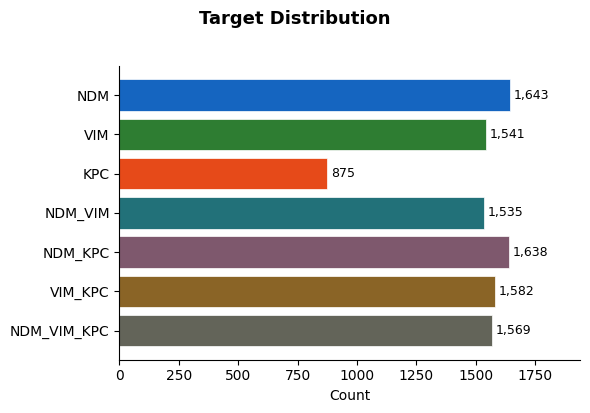

In [13]:
all_data = {}
for ds in DATASETS:
    d = joblib.load(DATA_ROOT / ds / 'curve_for_training_ml.joblib')
    all_data[ds] = d

# ── print tables ──────────────────────────────────────────────────────────────
for ds, d in all_data.items():
    mapped = [LABEL_REMAP.get(l, l) for l in d['well_labels']]
    cnt    = Counter(mapped)
    total  = sum(cnt.values())
    print(f'\n=== {ds}  (N={total:,}) ===')
    print(f'  all_targets : {d["all_targets"]}')
    print(f'  unique labels: {len(cnt)}')
    print(f'  {"Label":<18s}  {"N":>7s}  {"pct":>6s}  type')
    print('  ' + '-'*44)
    for lab in reversed(LABEL_ORDER):
        if lab not in cnt:
            continue
        n = cnt[lab]
        mtype = 'multi ' if '_' in lab else 'single'
        print(f'  {lab:<18s}  {n:>7,}  {n/total*100:>5.1f}%  {mtype}')

# ── bar charts ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(DATASETS), figsize=(12 * len(DATASETS) / 2, 4),
                         sharey=False, squeeze=False)
for ax, (ds, d) in zip(axes.flatten(), all_data.items()):
    mapped = [LABEL_REMAP.get(l, l) for l in d['well_labels']]
    cnt    = Counter(mapped)
    labels = [l for l in reversed(LABEL_ORDER) if l in cnt]
    vals   = [cnt[l] for l in labels]
    colors = []
    for lab in labels:
        parts = lab.split('_')
        if len(parts) == 1:
            colors.append(BASE_COLORS.get(lab, '#888'))
        else:
            rgbs = [matplotlib.colors.to_rgb(BASE_COLORS.get(p, '#888')) for p in parts]
            colors.append(tuple(sum(c[i] for c in rgbs) / len(rgbs) for i in range(3)))
    bars = ax.barh(labels, vals, color=colors, edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_width() + max(vals)*0.01, bar.get_y() + bar.get_height()/2,
                f'{v:,}', va='center', fontsize=9)
    # ax.set_title(ds, fontsize=11, fontweight='bold')
    ax.set_xlabel('Count')
    ax.set_xlim(0, max(vals) * 1.18)
    ax.spines[['top','right']].set_visible(False)

fig.suptitle('Target Distribution', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Curve Profiles per Target
Each subplot = one unique label.
- **Single targets**: all curves (low α) + bold mean.
- **Multi-targets**: all curves (low α) + bold mean + dashed means of constituent singles.

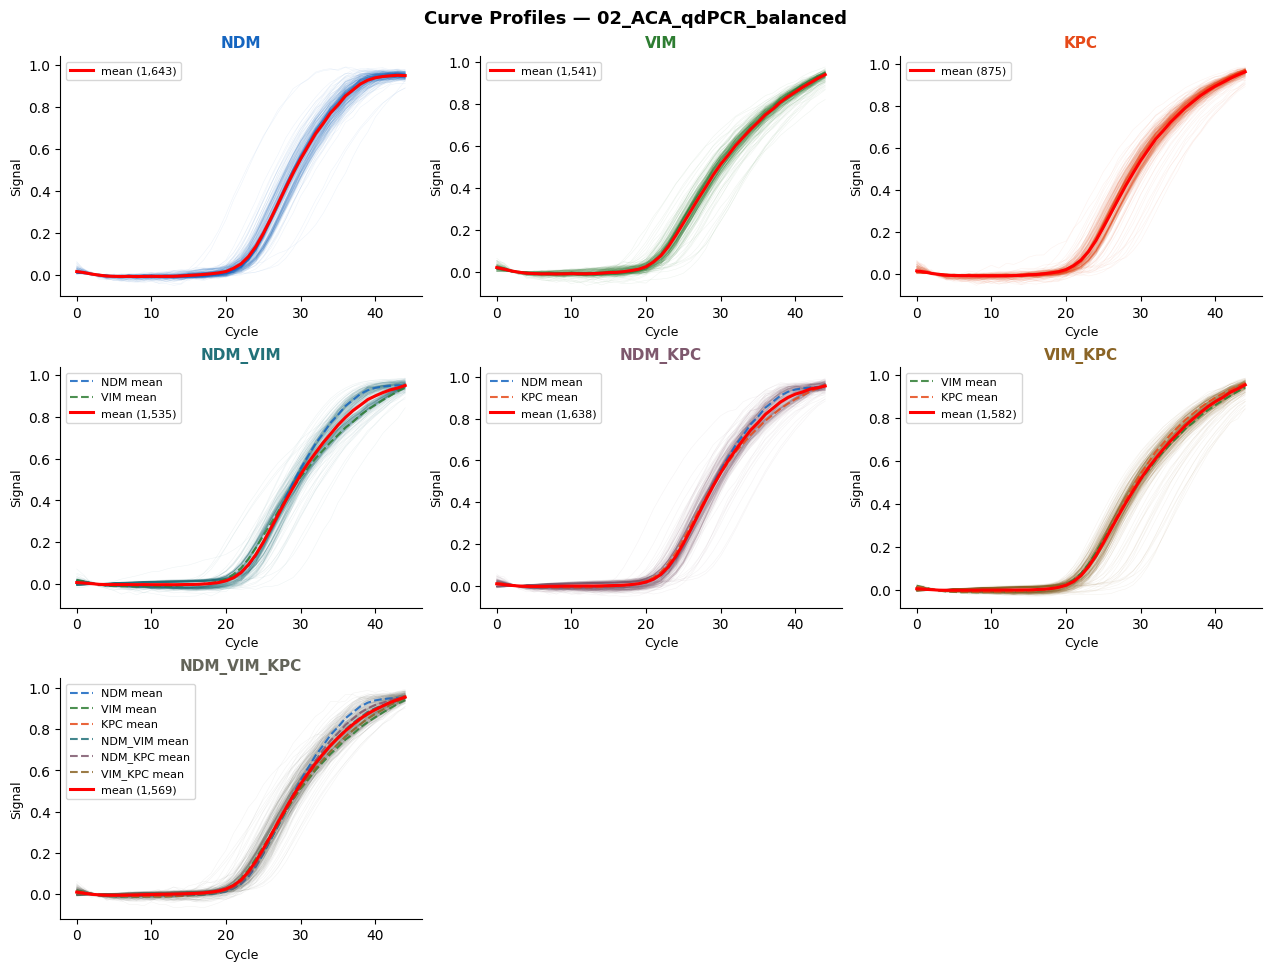

In [19]:
def _label_color(label):
    parts = label.split("_")
    if len(parts) == 1:
        return BASE_COLORS.get(label, "#888888")
    rgbs = [matplotlib.colors.to_rgb(BASE_COLORS.get(p, "#888888")) for p in parts]
    return tuple(sum(c[i] for c in rgbs) / len(rgbs) for i in range(3))


def _plot_dataset_curves(ax_map, d):
    raw     = np.array(d["well_labels"])
    labels  = np.array([LABEL_REMAP.get(l, l) for l in raw])
    curves  = d["curves"][CURVE_KEY]
    ts      = np.asarray(d["timestamps"])
    present = set(labels)

    # pre-compute means for every present label (used for subset dashed lines)
    all_means = {}
    for lab in LABEL_ORDER:
        if lab in present:
            idx = np.where(labels == lab)[0]
            all_means[lab] = curves[idx].mean(axis=0)

    for lab in LABEL_ORDER:
        if lab not in present or lab not in ax_map:
            continue
        ax  = ax_map[lab]
        col = _label_color(lab)
        idx = np.where(labels == lab)[0]
        sub = idx if len(idx) <= MAX_CURVES_PLOT else np.random.choice(idx, MAX_CURVES_PLOT, replace=False)

        for i in sub:
            ax.plot(ts, curves[i], color=col, alpha=0.075, linewidth=0.4, rasterized=True)

        

        lab_parts = frozenset(lab.split("_"))
        if len(lab_parts) > 1:
            # show dashed mean for every proper subset present in the dataset
            for sub_lab in LABEL_ORDER:
                if sub_lab == lab: continue
                if frozenset(sub_lab.split("_")) < lab_parts and sub_lab in all_means:
                    ax.plot(ts, all_means[sub_lab], color=_label_color(sub_lab),
                            linewidth=1.5, linestyle="--", alpha=0.85, label=f"{sub_lab} mean")
        
        mean_curve = curves[idx].mean(axis=0)
        ax.plot(ts, mean_curve, color='red', linewidth=2.2, label=f"mean ({len(idx):,})")

for ds, d in all_data.items():
    present    = {LABEL_REMAP.get(l, l) for l in d["well_labels"]}
    all_labels = [l for l in LABEL_ORDER if l in present]
    n_plots    = len(all_labels)
    ncols      = min(n_plots, 3)
    nrows      = math.ceil(n_plots / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.2, nrows * 3.2),
                             constrained_layout=True)
    axes_flat = np.array(axes).flatten() if n_plots > 1 else [axes]

    ax_map = {lab: axes_flat[i] for i, lab in enumerate(all_labels)}
    _plot_dataset_curves(ax_map, d)

    for i, lab in enumerate(all_labels):
        ax = axes_flat[i]
        ax.set_title(lab, fontsize=11, fontweight="bold", color=_label_color(lab))
        ax.set_xlabel("Cycle", fontsize=9)
        ax.set_ylabel("Signal", fontsize=9)
        ax.legend(fontsize=8, loc="upper left")
        ax.spines[["top","right"]].set_visible(False)

    for j in range(n_plots, len(axes_flat)):
        axes_flat[j].set_visible(False)

    fig.suptitle(f"Curve Profiles — {ds}", fontsize=13, fontweight="bold")
    plt.show()
